# Definición del Problema: Control de Calidad en Sensores de Turbinas
En una planta de energía, se monitorean dos variables críticas de las turbinas para determinar si el equipo requiere una parada de mantenimiento inmediata (Clase 1) o si puede seguir operando normalmente (Clase 0).

Variable $x_1$ (Vibración): Medida en milímetros por segundo (mm/s).

Variable $x_2$ (Temperatura): Medida en grados Celsius (°C).

Hipótesis de Modelizado: Se asume que existe una relación lineal donde, a mayor vibración y mayor temperatura, el riesgo de falla aumenta.

El objetivo es que el Perceptrón encuentre la línea exacta (hiperplano) que divide el estado operativo del estado crítico basándose en datos históricos.

## Solución del Problema con Keras
A continuación, se presenta la implementación del modelo. Se han seguido las directrices de optimización de código y comentarios restringidos a parámetros ajustables.

## Librerías y Preparación de Datos

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_blobs

# Generación de datos sintéticos linealmente separables
X, y = make_blobs(n_samples=500, centers=2, n_features=2, cluster_std=1.0, random_state=42)

## Construcción del Perceptrón Simple
En Keras, un perceptrón se define como una red con una única capa y una única unidad (neurona).

In [ ]:
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(2,)), # Define explícitamente la forma de entrada
    Dense(units=1, activation='sigmoid') # Ajustar activation según el tipo de salida deseada
])

## Configuración del Entrenamiento (Compilación)
Aquí definimos cómo aprenderá el modelo. Utilizaremos el Descenso de Gradiente Estocástico (SGD) y la Entropía Cruzada Binaria, que es la función de pérdida estándar para decisiones de "sí o no".

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1), # Ajustar learning_rate para controlar la velocidad de convergencia
    loss='binary_crossentropy', # Función de pérdida para clasificación binaria
    metrics=['accuracy']
)

## Ejecución del Modelizado

In [ ]:
history = model.fit(X, y, epochs=50, verbose=1) # Ajustar epochs según la complejidad del dataset

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0017     
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0016 
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0016 
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0016 
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0016 
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0015 
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0015 
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0015 
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0015     
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0014 
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0014     
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

## Análisis de la Solución Matemática
El modelo entrenado habrá calculado internamente un vector de pesos $W = [w_1, w_2]$ y un sesgo $b$. La decisión de la turbina se rige por la siguiente ecuación de frontera:$$w_1 \cdot \text{Vibración} + w_2 \cdot \text{Temperatura} + b = 0$$

Cualquier punto que resulte en un valor positivo tras pasar por la función Sigmoide ($> 0.5$) será clasificado como Mantenimiento Crítico.

Este sistema, una vez entrenado, permite la automatización del monitoreo en tiempo real. Si los sensores envían nuevos valores, el perceptrón realiza una operación de producto punto instantánea para emitir una alerta, emulando el comportamiento de una compuerta lógica basada en umbrales de seguridad industrial.

### Verificación de Resultados
Para validar si el modelo ha convergido correctamente, podemos consultar los pesos finales asignados a cada sensor:

In [ ]:
pesos, sesgo = model.layers[0].get_weights()
print(f"Peso Vibración: {pesos[0]}, Peso Temperatura: {pesos[1]}, Sesgo: {sesgo}")

Peso Vibración: [1.7911557], Peso Temperatura: [-0.503989], Sesgo: [0.33956552]


Si el peso de la vibración es significativamente mayor al de la temperatura, el sistema nos está indicando que, para este motor en particular, la vibración es un predictor de falla más crítico que el calor.

## Visualización del Entrenamiento

Podemos inspeccionar el objeto `history` devuelto por `model.fit()` para ver cómo evolucionaron la pérdida y la precisión durante el entrenamiento.

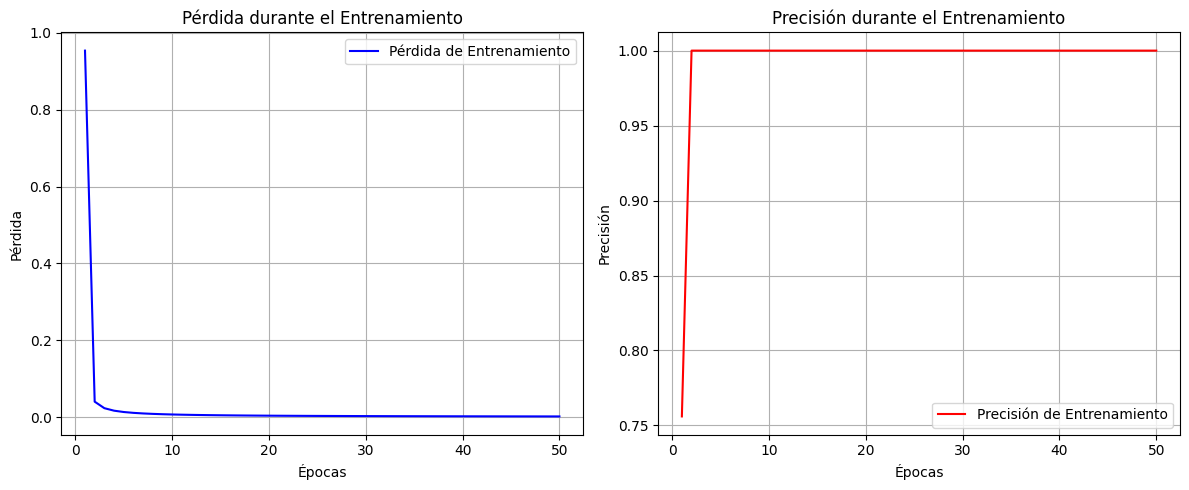

In [ ]:
import matplotlib.pyplot as plt

# Obtener los datos de pérdida y precisión del historial
loss = history.history['loss']
accuracy = history.history['accuracy']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))

# Gráfico de la pérdida
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(epochs, loss, 'b', label='Pérdida de Entrenamiento')
plt.title('Pérdida durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfico de la precisión
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(epochs, accuracy, 'r', label='Precisión de Entrenamiento')
plt.title('Precisión durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Visualización de la Frontera de Decisión

Ahora, podemos visualizar la línea de decisión (hiperplano) que el perceptrón ha aprendido para separar las dos clases.

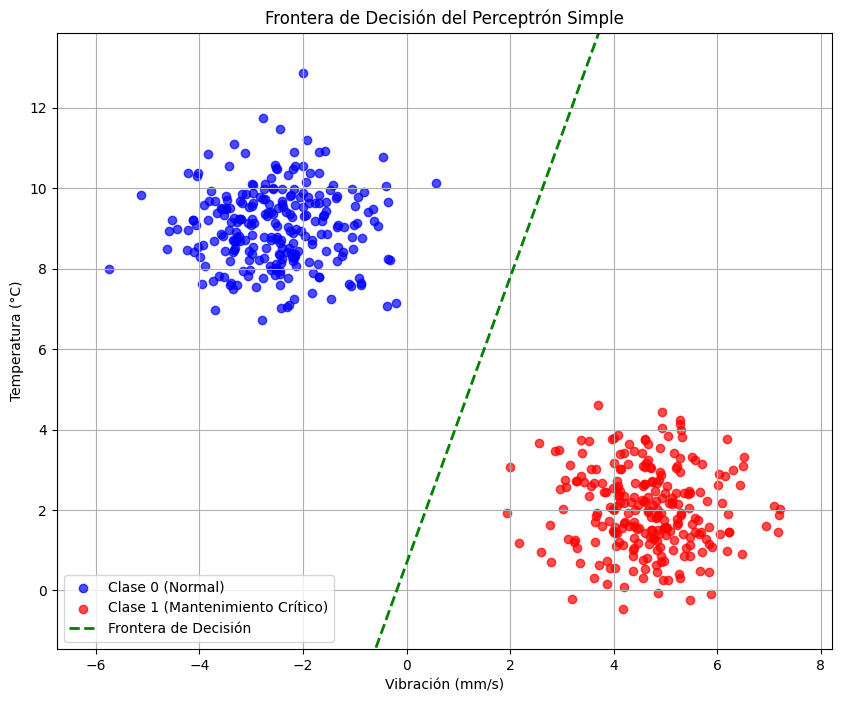

In [ ]:
import matplotlib.pyplot as plt

# Extraer los pesos y el sesgo del modelo
pesos, sesgo = model.layers[0].get_weights()

w1, w2 = pesos[0][0], pesos[1][0]
b = sesgo[0]

# La ecuación de la frontera de decisión es w1*x1 + w2*x2 + b = 0
# Para graficarla, la reescribimos como x2 = (-w1*x1 - b) / w2

# Determinar los límites para el gráfico
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

x1_line = np.linspace(x1_min, x1_max, 100)
x2_line = (-w1 * x1_line - b) / w2

plt.figure(figsize=(10, 8))

# Graficar los puntos de datos
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', label='Clase 0 (Normal)', alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='Clase 1 (Mantenimiento Crítico)', alpha=0.7)

# Graficar la frontera de decisión
plt.plot(x1_line, x2_line, color='green', linestyle='--', linewidth=2, label='Frontera de Decisión')

plt.title('Frontera de Decisión del Perceptrón Simple')
plt.xlabel('Vibración (mm/s)')
plt.ylabel('Temperatura (°C)')
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)
plt.legend()
plt.grid(True)
plt.show()